# Electric Vehicle Data Analysis

### Load The Libraries

In [3]:
##Import the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### Load The Dataset

In [4]:
#read the excel file dataset
df = pd.read_excel("FEV-data-Excel.xlsx")
df.head() #prints first five rows

,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
0,Audi e-tron 55 quattro,Audi,e-tron 55 quattro,345700,360,664,disc (front + rear),4WD,95.0,438,...,3130.0,640.0,5,5,19,200,660.0,5.7,150,24.45
1,Audi e-tron 50 quattro,Audi,e-tron 50 quattro,308400,313,540,disc (front + rear),4WD,71.0,340,...,3040.0,670.0,5,5,19,190,660.0,6.8,150,23.80
2,Audi e-tron S quattro,Audi,e-tron S quattro,414900,503,973,disc (front + rear),4WD,95.0,364,...,3130.0,565.0,5,5,20,210,660.0,4.5,150,27.55
3,Audi e-tron Sportback 50 quattro,Audi,e-tron Sportback 50 quattro,319700,313,540,disc (front + rear),4WD,71.0,346,...,3040.0,640.0,5,5,19,190,615.0,6.8,150,23.30
4,Audi e-tron Sportback 55 quattro,Audi,e-tron Sportback 55 quattro,357000,360,664,disc (front + rear),4WD,95.0,447,...,3130.0,670.0,5,5,19,200,615.0,5.7,150,23.85


### Overview of the Last Five EVs in the Dataset

In [5]:
# Display the last five rows of the DataFrame
df.tail()

,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
48,Volkswagen ID.3 Pro S,Volkswagen,ID.3 Pro S,179990,204,310,disc (front) + drum (rear),2WD (rear),77.0,549,...,2280.0,412.0,5,5,19,160,385.0,7.9,125,15.9
49,Volkswagen ID.4 1st,Volkswagen,ID.4 1st,202390,204,310,disc (front) + drum (rear),2WD (rear),77.0,500,...,2660.0,661.0,5,5,20,160,543.0,8.5,125,18.0
50,Citroën ë-Spacetourer (M),Citroën,ë-Spacetourer (M),215400,136,260,disc (front + rear),2WD (front),50.0,230,...,2810.0,1056.0,8,5,16,130,603.0,13.1,100,25.2
51,Mercedes-Benz EQV (long),Mercedes-Benz,EQV (long),339480,204,362,NaN,2WD (front),90.0,356,...,3500.0,865.0,6,5,17,160,NaN,NaN,110,28.2
52,Nissan e-NV200 evalia,Nissan,e-NV200 evalia,164328,109,254,disc (front + rear),2WD (front),40.0,200,...,2250.0,658.0,5,5,15,123,870.0,NaN,50,25.9


## Dataset Dimensions – Total Records Overview

In [6]:
# Total Records
print(f"Total Rows in the dataset: {df.shape[0]}")
print(f"Total Columns in the dataset: {df.shape[1]}")

Total Rows in the dataset: 53
Total Columns in the dataset: 25


##### The dataset contains detailed specifications for 53 electric vehicles, with 25 attributes each, offering a comprehensive base for analysis on performance, efficiency, pricing, and more.

### Dataset Summary – Structure and Data Types Overview

In [7]:
#dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 25 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Car full name                           53 non-null     object 
 1   Make                                    53 non-null     object 
 2   Model                                   53 non-null     object 
 3   Minimal price (gross) [PLN]             53 non-null     int64  
 4   Engine power [KM]                       53 non-null     int64  
 5   Maximum torque [Nm]                     53 non-null     int64  
 6   Type of brakes                          52 non-null     object 
 7   Drive type                              53 non-null     object 
 8   Battery capacity [kWh]                  53 non-null     float64
 9   Range (WLTP) [km]                       53 non-null     int64  
 10  Wheelbase [cm]                          53 non-null     float64


### Statistical Summary of Numerical Features in the EV Dataset

In [8]:
#statistical summary
df.describe()

,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Battery capacity [kWh],Range (WLTP) [km],Wheelbase [cm],Length [cm],Width [cm],Height [cm],Minimal empty weight [kg],Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,45.000000,45.000000,53.000000,53.000000,53.000000,53.000000,52.000000,50.00000,53.000000,44.000000
mean,246158.509434,269.773585,460.037736,62.366038,376.905660,273.581132,442.509434,186.241509,155.422642,1868.452830,2288.844444,520.466667,4.905660,4.849057,17.679245,178.169811,445.096154,7.36000,113.509434,18.994318
std,149187.485190,181.298589,261.647000,24.170913,118.817938,22.740518,48.863280,14.280641,11.275358,470.880867,557.796026,140.682848,0.838133,0.455573,1.868500,43.056196,180.178480,2.78663,57.166970,4.418253
min,82050.000000,82.000000,160.000000,17.600000,148.000000,187.300000,269.500000,164.500000,137.800000,1035.000000,1310.000000,290.000000,2.000000,3.000000,14.000000,123.000000,171.000000,2.50000,22.000000,13.100000
25%,142900.000000,136.000000,260.000000,40.000000,289.000000,258.800000,411.800000,178.800000,148.100000,1530.000000,1916.000000,440.000000,5.000000,5.000000,16.000000,150.000000,315.000000,4.87500,100.000000,15.600000
50%,178400.000000,204.000000,362.000000,58.000000,364.000000,270.000000,447.000000,180.900000,155.600000,1685.000000,2119.000000,486.000000,5.000000,5.000000,17.000000,160.000000,425.000000,7.70000,100.000000,17.050000
75%,339480.000000,372.000000,640.000000,80.000000,450.000000,290.000000,490.100000,193.500000,161.500000,2370.000000,2870.000000,575.000000,5.000000,5.000000,19.000000,200.000000,558.000000,9.37500,150.000000,23.500000
max,794000.000000,772.000000,1140.000000,100.000000,652.000000,327.500000,514.000000,255.800000,191.000000,2710.000000,3500.000000,1056.000000,8.000000,5.000000,21.000000,261.000000,870.000000,13.10000,270.000000,28.200000


### Missing Values Report – Null Value Count per Column

In [9]:
df.isnull().sum()

Car full name                             0
Make                                      0
Model                                     0
Minimal price (gross) [PLN]               0
Engine power [KM]                         0
Maximum torque [Nm]                       0
Type of brakes                            1
Drive type                                0
Battery capacity [kWh]                    0
Range (WLTP) [km]                         0
Wheelbase [cm]                            0
Length [cm]                               0
Width [cm]                                0
Height [cm]                               0
Minimal empty weight [kg]                 0
Permissable gross weight [kg]             8
Maximum load capacity [kg]                8
Number of seats                           0
Number of doors                           0
Tire size [in]                            0
Maximum speed [kph]                       0
Boot capacity (VDA) [l]                   1
Acceleration 0-100 kph [s]      

### Missing Data Handling – Imputation Strategy and Execution

In [10]:
df['Type of brakes'].fillna(df['Type of brakes'].mode()[0], inplace = True)
df['Permissable gross weight [kg]'].fillna(df['Permissable gross weight [kg]'].median(), inplace = True)
df['Maximum load capacity [kg]'].fillna(df['Maximum load capacity [kg]'].median(), inplace = True)
df['Boot capacity (VDA) [l]'].fillna(df['Boot capacity (VDA) [l]'].mode()[0], inplace = True)
df['Acceleration 0-100 kph [s]'].fillna(df['Acceleration 0-100 kph [s]'].mode()[0], inplace = True)
df['mean - Energy consumption [kWh/100 km]'].fillna(df['mean - Energy consumption [kWh/100 km]'].mode()[0], inplace = True)

1. 11 missing values have now been resolved, resulting in a clean and complete dataset.
2. The imputation strategy preserved data distribution and avoided distortion of means or variances.
3. Chosen methods (mode/median) are robust against skewed data or outliers, ensuring reliability for downstream analysis.

In [11]:
df.isna().sum().sum()

0

## Task 1 A customer has a budget of 350,000 PLN and wants an EV with a minimum range of 400 km.
1. Your task is to filter out EVs that meet these criteria.
2. Group them by the manufacturer (Make).
3. Calculate the average battery capacity for each manufacturer.

In [12]:
# Filter based on budget and range
filtered_evs = df[
    (df['Minimal price (gross) [PLN]'] <= 350000) &
    (df['Range (WLTP) [km]'] >= 400)
]

filtered_evs[['Car full name', 'Make', 'Minimal price (gross) [PLN]', 'Range (WLTP) [km]', 'Battery capacity [kWh]']]


,Car full name,Make,Minimal price (gross) [PLN],Range (WLTP) [km],Battery capacity [kWh]
0,Audi e-tron 55 quattro,Audi,345700,438,95.0
8,BMW iX3,BMW,282900,460,80.0
15,Hyundai Kona electric 64kWh,Hyundai,178400,449,64.0
18,Kia e-Niro 64kWh,Kia,167990,455,64.0
20,Kia e-Soul 64kWh,Kia,160990,452,64.0
22,Mercedes-Benz EQC,Mercedes-Benz,334700,414,80.0
39,Tesla Model 3 Standard Range Plus,Tesla,195490,430,54.0
40,Tesla Model 3 Long Range,Tesla,235490,580,75.0
41,Tesla Model 3 Performance,Tesla,260490,567,75.0
47,Volkswagen ID.3 Pro Performance,Volkswagen,155890,425,58.0


## Insights:
1. 12 EVs meet the criteria: ≤ 350,000 PLN and ≥ 400 km range.
2. These models are offered by 7 manufacturers: Audi, BMW, Hyundai, Kia, Mercedes-Benz, Tesla, Volkswagen.
3. Tesla, Volkswagen, and Kia offer multiple models that meet the budget and range criteria, indicating strong value offerings in the mid-price EV segment.

In [13]:
# Task 1b & 1c: Group by Make and calculate average battery capacity
grouped = filtered_evs.groupby('Make')['Battery capacity [kWh]'].mean().reset_index()
grouped.rename(columns={'Battery capacity [kWh]': 'Average Battery Capacity [kWh]'}, inplace=True)

grouped

,Make,Average Battery Capacity [kWh]
0,Audi,95.000000
1,BMW,80.000000
2,Hyundai,64.000000
3,Kia,64.000000
4,Mercedes-Benz,80.000000
5,Tesla,68.000000
6,Volkswagen,70.666667


## Insights:
### Average battery capacity by make:
1. Audi: 95.0 kWh (highest)
2. Tesla: 68.0 kWh (efficient relative to range)
3. Volkswagen: ~70.7 kWh
4. Kia & Hyundai: 64.0 kWh (excellent efficiency)

## Recommendations From Task 1:
1. Highlight Kia, Hyundai, and Volkswagen to value-seeking customers—offering solid range at competitive prices.
2. Promote Tesla to users interested in long-range, high-efficiency EVs under budget

 ## Task 2: You suspect some EVs have unusually high or low energy consumption. 
### Find the outliers in the mean- Energy consumption [kWh/100 km] column.

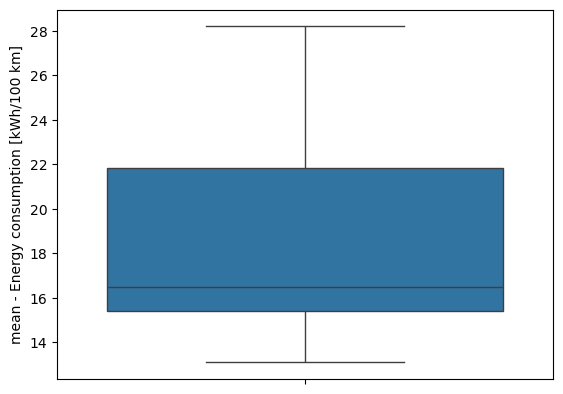

In [14]:
sns.boxplot(df['mean - Energy consumption [kWh/100 km]'])
plt.show()

## Insights:
1. No statistical outliers found in mean - Energy consumption [kWh/100 km].
2. Indicates consistent energy consumption values across all EVs in the dataset.
3. Suggests data quality is high, and EV performance (in terms of efficiency) is relatively standardized

In [15]:
# Task 2: Detect outliers in energy consumption using IQR method
Q1 = df['mean - Energy consumption [kWh/100 km]'].quantile(0.25)
Q3 = df['mean - Energy consumption [kWh/100 km]'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['mean - Energy consumption [kWh/100 km]'] < lower_bound) | (df['mean - Energy consumption [kWh/100 km]'] > upper_bound)]

# Display relevant columns
outliers[['Car full name', 'Make', 'mean - Energy consumption [kWh/100 km]']]


,Car full name,Make,mean - Energy consumption [kWh/100 km]


## Recommendation From Task 2:
No immediate need to clean or investigate energy consumption data—safe to use for modeling or customer comparison tools.



## Task 3: Your manager wants to know if there's a strong relationship between battery capacity and range.
1. Create a suitable plot to visualize.
2. Highlight any insights.

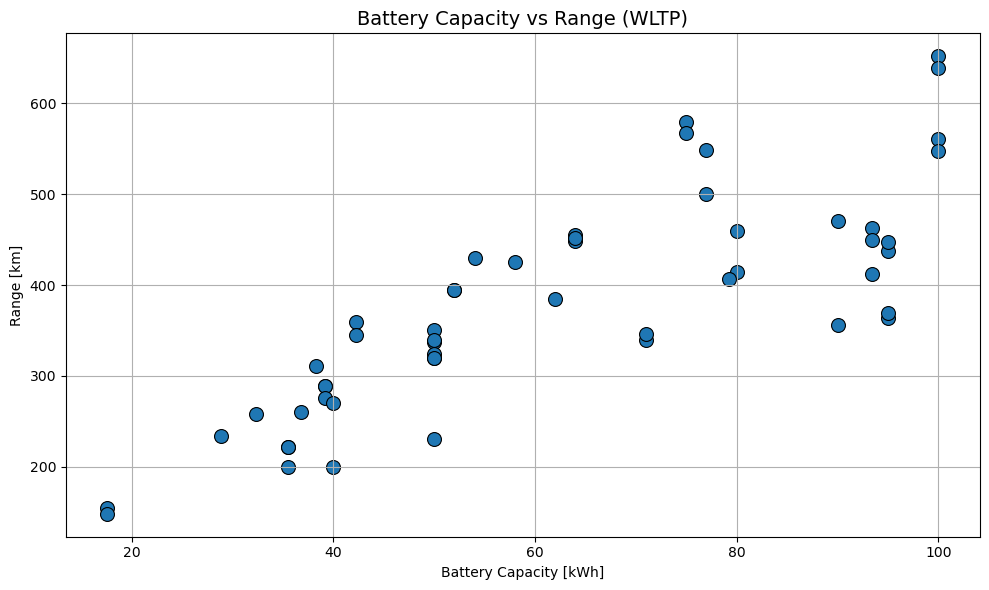

In [28]:
#Scatter plot of Battery Capacity vs. Range
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Battery capacity [kWh]',
    y='Range (WLTP) [km]',
    
    palette='tab10',
    s=100,
    edgecolor='black'
)

plt.title('Battery Capacity vs Range (WLTP)', fontsize=14)
plt.xlabel('Battery Capacity [kWh]')
plt.ylabel('Range [km]')
plt.grid(True)
#plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Insights From Task 3:
1. **Positive Correlation:**
There’s a clear positive relationship—larger battery capacity generally leads to a higher range.

2. **Efficiency Differences:**
Some makes (e.g., Tesla, Hyundai, Kia) achieve better range with smaller batteries, indicating better energy efficiency.

3. **Luxury EVs (e.g., Audi, Mercedes-Benz):**
Often have large batteries (80–95 kWh) but moderate range, likely due to higher weight and performance demands.

## Recommendations From Task 3:
1. Emphasize efficiency (not just battery size) in marketing or customer decision tools.
2. Consider visual battery-range tradeoffs when suggesting EVs to users.

## Task 4: Build an EV recommendation class. 

In [29]:
#Define the EV recommendation class

class EVRecommender:
    def __init__(self, data):
        self.data = data.copy()

    def recommend(self, budget, desired_range, min_battery_capacity):
        # Filter based on user criteria
        results = self.data[
            (self.data['Minimal price (gross) [PLN]'] <= budget) &
            (self.data['Range (WLTP) [km]'] >= desired_range) &
            (self.data['Battery capacity [kWh]'] >= min_battery_capacity)
        ]

        # Sort by price for best value and return top 3
        top_matches = results.sort_values(by='Minimal price (gross) [PLN]').head(3)
        return top_matches[['Car full name', 'Make', 'Minimal price (gross) [PLN]',
                            'Range (WLTP) [km]', 'Battery capacity [kWh]']]

# Instantiate the class
recommender = EVRecommender(df)

# Example: Test with a sample input
recommender.recommend(budget=300000, desired_range=450, min_battery_capacity=60)


,Car full name,Make,Minimal price (gross) [PLN],Range (WLTP) [km],Battery capacity [kWh]
20,Kia e-Soul 64kWh,Kia,160990,452,64.0
18,Kia e-Niro 64kWh,Kia,167990,455,64.0
48,Volkswagen ID.3 Pro S,Volkswagen,179990,549,77.0


## Insights:
### The recommender class efficiently narrows down EVs based on:
1. Budget
2. Desired range
3. Battery size
### Result:
1. Kia e-Soul 64kWh
2. Kia e-Niro 64kWh
3. Volkswagen ID.3 Pro S

## Recommendations:
1. Integrate the class into a user-facing app or website.
2. Use it for automated customer queries or dealer tools to match EVs with user preferences.



## Task 5: Inferential Statistics– Hypothesis Testing

In [30]:
from scipy.stats import ttest_ind

# Extract engine power data for Tesla and Audi
tesla_power = df[df['Make'] == 'Tesla']['Engine power [KM]']
audi_power = df[df['Make'] == 'Audi']['Engine power [KM]']

# Perform two-sample t-test
t_stat, p_value = ttest_ind(tesla_power, audi_power, equal_var=False)

t_stat, p_value


(1.7939951827297178, 0.10684105068839565)

## Insights:
1. p-value = 0.107 → Not statistically significant at 95% confidence.
2. Suggests Tesla and Audi have comparable engine power despite differences in brand positioning and design.

## Recommendation From Task 5:
#### When comparing Tesla and Audi, focus less on power specs - emphasize features, software, efficiency, or brand loyalty instead.

## Final Recommendations & Business Applications
1. Promote high-efficiency EVs (Kia, Hyundai, Tesla) to customers prioritizing range over size or luxury.
2. Educate users on the battery–range relationship and how efficiency can vary.
3. Integrate the recommendation engine into digital tools for showrooms, sales teams, or online platforms.

### Use this analysis as a base for:
1. Custom offers
2. Pricing adjustments
3. Predictive modeling (e.g., customer preferences, resale value, TCO)
4. Target specific customer segments based on budget and range preferences using the grouped manufacturer data.